In [ ]:
## 3) Atividade Práticas Experimentais


In [ ]:
## 3.1 - Correção de Ponto Branco (White Point Correction)

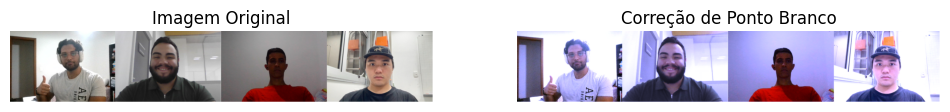

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Garantindo que a função de plotagem existe nesta célula
def mostrar_comparacao(img1, img2, titulo1, titulo2, cmap1=None, cmap2=None):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    if cmap1: plt.imshow(img1, cmap=cmap1)
    else: plt.imshow(img1)
    plt.title(titulo1)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    if cmap2: plt.imshow(img2, cmap=cmap2)
    else: plt.imshow(img2)
    plt.title(titulo2)
    plt.axis('off')
    plt.show()

# 2. Função de Correção de Ponto Branco [cite: 17]
def white_point_correction(img, sourcewp, targetwp):
    corrected = img * (targetwp / sourcewp)
    return np.clip(corrected, 0, 1)

# 3. Carregando a imagem de forma segura (Substitua 'sua_foto_aqui.jpg' pelo nome correto!)
img_bgr = cv2.imread('imagem_grupo.png') 

if img_bgr is None:
    print("ERRO: A imagem não foi encontrada! Verifique se o nome do arquivo está correto e na mesma pasta.")
else:
    # Converte para RGB e normaliza para a escala [0, 1]
    img_grupo_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_grupo_norm = img_grupo_rgb / 255.0

    # Definindo pontos brancos hipotéticos (ex: corrigindo luz quente para neutra)
    source_wp = np.array([0.8, 0.8, 0.5]) 
    target_wp = np.array([1.0, 1.0, 1.0]) 

    # Aplicando a correção
    img_wp_corrigida = white_point_correction(img_grupo_norm, source_wp, target_wp)

    # Mostrando o resultado
    mostrar_comparacao(img_grupo_norm, img_wp_corrigida, 
                       'Imagem Original', 'Correção de Ponto Branco')

In [ ]:
## 3.2 - Transformação XYZ para RGB e Correção Gama

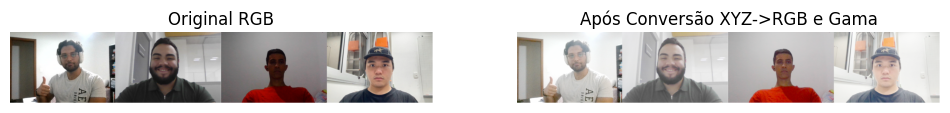

In [4]:
def xyz_to_rgb_gamma(xyz_img):
    # Matriz de conversão linear XYZ para RGB (D65)
    matrix = np.array([[3.2406, -1.5372, -0.4986],
                       [-0.9689, 1.8758, 0.0415],
                       [0.0557, -0.2040, 1.0570]])

    rgb_linear = xyz_img @ matrix.T
    rgb_linear = np.clip(rgb_linear, 0, 1)

    # Correção Gama padrão sRGB
    gamma_corrected = np.where(rgb_linear <= 0.0031308,
                               12.92 * rgb_linear,
                               1.055 * np.power(rgb_linear, 1/2.4) - 0.055)
    return gamma_corrected

# Convertendo a imagem RGB do grupo para XYZ float32
img_float32 = img_grupo_norm.astype(np.float32)
img_xyz = cv2.cvtColor(img_float32, cv2.COLOR_RGB2XYZ)

# Aplicando a conversão e correção gama
img_gama_corrigida = xyz_to_rgb_gamma(img_xyz)

mostrar_comparacao(img_grupo_norm, img_gama_corrigida, 
                   'Original RGB', 'Após Conversão XYZ->RGB e Gama')

In [ ]:
## 3.3 - O Modelo CIELAB

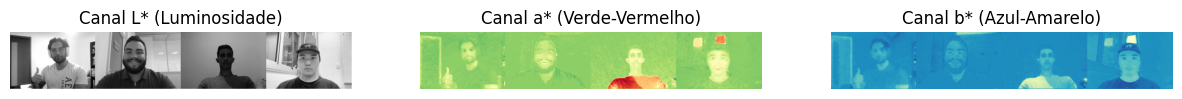

In [7]:
# Convertendo para LAB usando a variável 'img_bgr' que já foi lida pelo imread nas células anteriores
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab)
l_chan, a_chan, b_chan = cv2.split(img_lab)

# Plotando os canais separadamente
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(l_chan, cmap='gray'), plt.title('Canal L* (Luminosidade)')
plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(a_chan, cmap='RdYlGn_r'), plt.title('Canal a* (Verde-Vermelho)')
plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(b_chan, cmap='YlGnBu_r'), plt.title('Canal b* (Azul-Amarelo)')
plt.axis('off')
plt.show()

In [ ]:
## 3.4 - Cores Dependentes de Câmera: HSV e sRGB

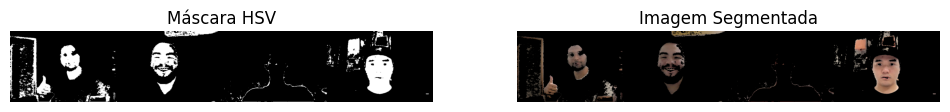

In [10]:
# Convertendo para HSV (Corrigido para img_bgr)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Exemplo didático: Criando uma máscara para tons de pele/vermelho/laranja
# (Ajuste os valores de lower e upper dependendo da iluminação da foto!)
lower_color = np.array([0, 30, 60])
upper_color = np.array([20, 150, 255])

mask_hsv = cv2.inRange(img_hsv, lower_color, upper_color)
segmentado_hsv = cv2.bitwise_and(img_grupo_rgb, img_grupo_rgb, mask=mask_hsv)

mostrar_comparacao(mask_hsv, segmentado_hsv, 
                   'Máscara HSV', 'Imagem Segmentada', cmap1='gray')

In [ ]:
## 3.5 - Modelo YCbCr

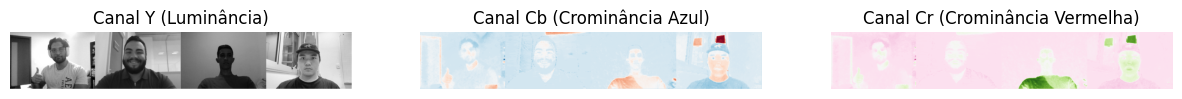

In [11]:
def rgb_to_ycbcr(rgb_img):
    # Coeficientes da transformação BT.601
    transform_mat = np.array([[0.299, 0.587, 0.114],
                              [-0.1687, -0.3313, 0.5],
                              [0.5, -0.4187, -0.0813]])
    ycbcr = rgb_img @ transform_mat.T
    ycbcr[:,:,1:] += 0.5 # Ajuste de offset para Cb e Cr
    return np.clip(ycbcr, 0, 1)

# Aplicando a transformação na imagem normalizada
img_ycbcr_manual = rgb_to_ycbcr(img_grupo_norm)

Y_ch = img_ycbcr_manual[:, :, 0]
Cb_ch = img_ycbcr_manual[:, :, 1]
Cr_ch = img_ycbcr_manual[:, :, 2]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(Y_ch, cmap='gray'), plt.title('Canal Y (Luminância)')
plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(Cb_ch, cmap='RdBu'), plt.title('Canal Cb (Crominância Azul)')
plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(Cr_ch, cmap='PiYG'), plt.title('Canal Cr (Crominância Vermelha)')
plt.axis('off')
plt.show()

In [ ]:
## 3.6 - Correção do ponto branco e gama 

In [2]:
import cv2
import numpy as np

# Funções auxiliares
def white_point_correction(img, sourcewp, targetwp):
    corrected = img * (targetwp / sourcewp)
    return np.clip(corrected, 0, 1)

def apply_gamma(rgb_linear):
    gamma_corrected = np.where(rgb_linear <= 0.0031308,
                               12.92 * rgb_linear,
                               1.055 * np.power(rgb_linear, 1/2.4) - 0.055)
    return np.clip(gamma_corrected, 0, 1)

# Inicia a captura de vídeo da webcam
cap = cv2.VideoCapture(0)

# --- CONFIGURAÇÃO DA GRAVAÇÃO DE VÍDEO ---
largura = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
altura = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = 20.0 # Taxa de quadros por segundo
fourcc = cv2.VideoWriter_fourcc(*'XVID') # Codec de vídeo
# Cria o objeto que vai gravar o vídeo
out = cv2.VideoWriter('3_6_video_demonstrativo.avi', fourcc, fps, (largura, altura))
# -----------------------------------------

modo = 1 
source_wp = np.array([0.7, 0.8, 1.0]) 
target_wp = np.array([1.0, 1.0, 1.0]) 

print("GRAVANDO VÍDEO... Pressione Q para parar e salvar.")
print("Controles: 1 (Original) | 2 (Ponto Branco) | 3 (Gama) | 4 (Ambos)")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Normaliza a imagem
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) / 255.0
    resultado_rgb = img_rgb.copy()

    # Aplica os filtros
    if modo == 2 or modo == 4:
        resultado_rgb = white_point_correction(resultado_rgb, source_wp, target_wp)
    if modo == 3 or modo == 4:
        resultado_rgb = apply_gamma(resultado_rgb)

    # Converte de volta para exibição
    resultado_bgr = cv2.cvtColor((resultado_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)

    # Criação do texto na tela
    exibicao = resultado_bgr.copy()
    cv2.putText(exibicao, f"Modo atual: {modo}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    
    cv2.imshow('3.6 - Gravando Webcam', exibicao)
    
    # SALVA O FRAME ATUAL NO VÍDEO
    out.write(exibicao)

    # Controles de teclado
    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):
        break
    elif key == ord('1'): modo = 1
    elif key == ord('2'): modo = 2
    elif key == ord('3'): modo = 3
    elif key == ord('4'): modo = 4

print("Vídeo 3.6 salvo com sucesso!")
cap.release()
out.release() # Finaliza o arquivo de vídeo
cv2.destroyAllWindows()

GRAVANDO VÍDEO... Pressione Q para parar e salvar.
Controles: 1 (Original) | 2 (Ponto Branco) | 3 (Gama) | 4 (Ambos)
Vídeo 3.6 salvo com sucesso!


In [ ]:
## 3.7 - Detecção de Cor pelo Método HSV

In [3]:
import cv2
import numpy as np

def nothing(x):
    pass

cap = cv2.VideoCapture(0)

# --- CONFIGURAÇÃO DA GRAVAÇÃO DE VÍDEO ---
largura = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
altura = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = 20.0
fourcc = cv2.VideoWriter_fourcc(*'XVID')
# A largura é multiplicada por 2 porque colocamos as duas imagens lado a lado (hstack)
out = cv2.VideoWriter('3_7_video_demonstrativo.avi', fourcc, fps, (largura * 2, altura))
# -----------------------------------------

cv2.namedWindow('Controles HSV')
cv2.createTrackbar('H Min', 'Controles HSV', 90, 179, nothing) # Começando perto do Azul
cv2.createTrackbar('S Min', 'Controles HSV', 100, 255, nothing)
cv2.createTrackbar('V Min', 'Controles HSV', 50, 255, nothing)
cv2.createTrackbar('H Max', 'Controles HSV', 130, 179, nothing)
cv2.createTrackbar('S Max', 'Controles HSV', 255, 255, nothing)
cv2.createTrackbar('V Max', 'Controles HSV', 255, 255, nothing)

print("GRAVANDO VÍDEO... Pressione Q para parar e salvar.")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    h_min = cv2.getTrackbarPos('H Min', 'Controles HSV')
    s_min = cv2.getTrackbarPos('S Min', 'Controles HSV')
    v_min = cv2.getTrackbarPos('V Min', 'Controles HSV')
    h_max = cv2.getTrackbarPos('H Max', 'Controles HSV')
    s_max = cv2.getTrackbarPos('S Max', 'Controles HSV')
    v_max = cv2.getTrackbarPos('V Max', 'Controles HSV')

    lower_color = np.array([h_min, s_min, v_min])
    upper_color = np.array([h_max, s_max, v_max])

    mask = cv2.inRange(hsv, lower_color, upper_color)
    resultado_segmentado = cv2.bitwise_and(frame, frame, mask=mask)

    # Junta as imagens
    tela_dividida = np.hstack((frame, resultado_segmentado))

    cv2.imshow('3.7 - Gravando HSV', tela_dividida)
    
    # SALVA O FRAME DIVIDIDO NO VÍDEO
    out.write(tela_dividida)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

print("Vídeo 3.7 salvo com sucesso!")
cap.release()
out.release() # Finaliza o arquivo de vídeo
cv2.destroyAllWindows()

GRAVANDO VÍDEO... Pressione Q para parar e salvar.
Vídeo 3.7 salvo com sucesso!


In [ ]:
## 4) Exercícios Propostos

In [ ]:
## 4.1 - Comparação de Luminosidade

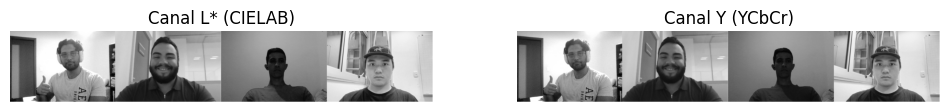

In [5]:
import cv2
import matplotlib.pyplot as plt

# 1. Garantindo que a função de plotagem existe na memória
def mostrar_comparacao(img1, img2, titulo1, titulo2, cmap1=None, cmap2=None):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    if cmap1: plt.imshow(img1, cmap=cmap1)
    else: plt.imshow(img1)
    plt.title(titulo1)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    if cmap2: plt.imshow(img2, cmap=cmap2)
    else: plt.imshow(img2)
    plt.title(titulo2)
    plt.axis('off')
    plt.show()

# 2. Carregando a imagem novamente (NÃO ESQUEÇA DE COLOCAR O NOME DA SUA FOTO AQUI)
img_bgr = cv2.imread('imagem_grupo.png')

if img_bgr is None:
    print("ERRO: A imagem não foi encontrada! Verifique se o nome do arquivo está correto e na mesma pasta.")
else:
    # 3. Fazendo as conversões (Exercício 1)
    img_lab_ex1 = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab)
    l_chan_ex1, a_chan, b_chan = cv2.split(img_lab_ex1)

    img_ycbcr_ex1 = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
    y_chan_ex1, cr_chan, cb_chan = cv2.split(img_ycbcr_ex1)

    # 4. Exibindo o resultado
    mostrar_comparacao(l_chan_ex1, y_chan_ex1, 
                       'Canal L* (CIELAB)', 'Canal Y (YCbCr)', 
                       cmap1='gray', cmap2='gray')

**Resposta (Exercício 1):**
O canal **$L$ (CIELAB)** preserva melhor os detalhes de sombreamento de forma alinhada à percepção original. Isso ocorre porque o espaço CIELAB foi projetado para ser perceptualmente uniforme em relação à visão humana. Já o canal $Y$ (Luminância do YCbCr) é uma combinação linear simples dos canais RGB otimizada para transmissão e compressão de vídeo, e não estritamente para a percepção humana de brilho e contraste.